In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm


In [31]:
train_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/splits/train.parquet")

rank_cols = [col for col in train_df.columns if '_rank' in col]
train_df = train_df.drop(columns=rank_cols)

test_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/splits/test.parquet")

rank_cols = [col for col in test_df.columns if '_rank' in col]
test_df = test_df.drop(columns=rank_cols)

val_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/splits/val.parquet")

rank_cols = [col for col in val_df.columns if '_rank' in col]
val_df = val_df.drop(columns=rank_cols)

# Verify splits
print("="*60)
print("TEMPORAL SPLITS")
print("="*60)
print(f"Train period: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"  Shape: {train_df.shape}")

print(f"\nVal period: {val_df['date'].min()} → {val_df['date'].max()}")
print(f"  Shape: {val_df.shape}")

print(f"\nTest period: {test_df['date'].min()} → {test_df['date'].max()}")
print(f"  Shape: {test_df.shape}")

# Verify no overlap
assert train_df['date'].max() < val_df['date'].min(), "❌ Train/Val overlap!"
assert val_df['date'].max() < test_df['date'].min(), "❌ Val/Test overlap!"
print("\n✅ No temporal overlap between splits")

TEMPORAL SPLITS
Train period: 2011-01-03 00:00:00 → 2021-12-31 00:00:00
  Shape: (109284, 37)

Val period: 2022-01-03 00:00:00 → 2023-06-30 00:00:00
  Shape: (15000, 37)

Test period: 2023-07-03 00:00:00 → 2024-11-27 00:00:00
  Shape: (14240, 37)

✅ No temporal overlap between splits


In [32]:
feature_cols = [c for c in train_df.columns if c not in ["date", "ticker", "fwd_return_5d"]]
print(len(feature_cols))


34


-------

1. Kolmogorov–Smirnov two-sample test

Tests if these two samples drawn from the same distribution

Checks the maximum vertical distance between their CDFs (stat is magnitude of difference and pval is probability that they come from same distribution)

2. Earth Mover’s Distance

Checks how much mass needs to move to transform one distribution into the other. Larger value means more drift, 0 mean identical

These 2 tell us: Whether your model is being trained and evaluated on the same market reality

In [33]:
from scipy.stats import ks_2samp, wasserstein_distance

drift_stats = []

for feat in feature_cols:
    train_vals = train_df[feat].dropna()
    val_vals   = val_df[feat].dropna()

    ks_stat, ks_p = ks_2samp(train_vals, val_vals)
    w_dist = wasserstein_distance(train_vals, val_vals)

    drift_stats.append({
        "feature": feat,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "wasserstein": w_dist
    })

drift_df = pd.DataFrame(drift_stats).sort_values("ks_stat", ascending=False)
drift_df.head(10)

,feature,ks_stat,ks_pvalue,wasserstein
0,dollar_volume,0.396801,0.0,1.746549e+09
29,dollar_vol_log,0.396801,0.0,8.661470e-01
5,price_ma_ratio_252,0.310831,0.0,1.150406e-01
20,vol_63,0.305965,0.0,4.747506e-03
19,vol_21,0.277739,0.0,4.739859e-03
24,downside_vol_1d,0.254745,0.0,2.851977e-03
18,vol_10,0.250266,0.0,4.621770e-03
25,downside_vol_5d,0.246709,0.0,6.636532e-03
23,hl_range,0.246444,0.0,6.063795e-03
17,vol_5,0.220265,0.0,4.467616e-03


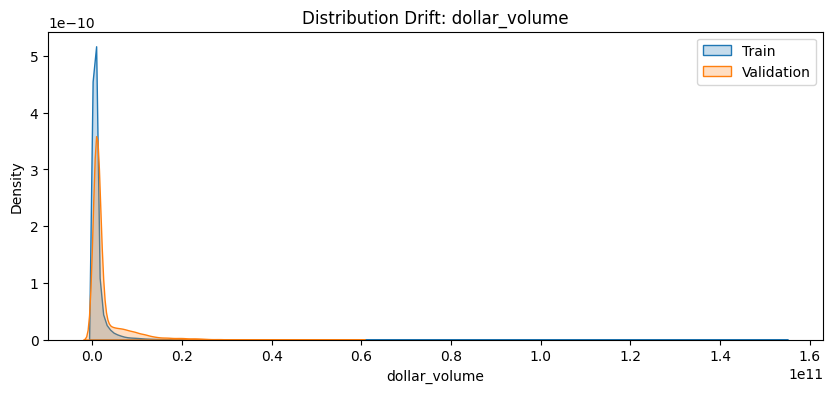

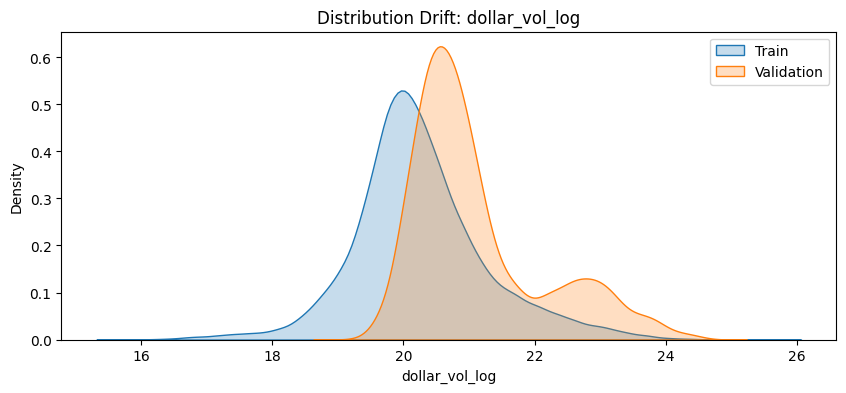

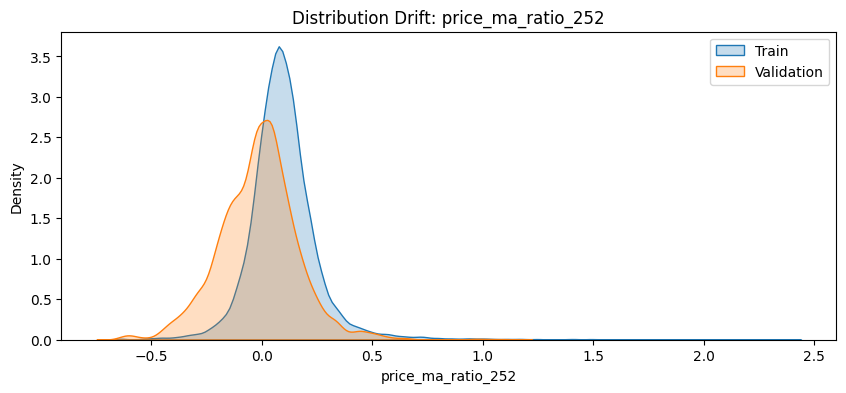

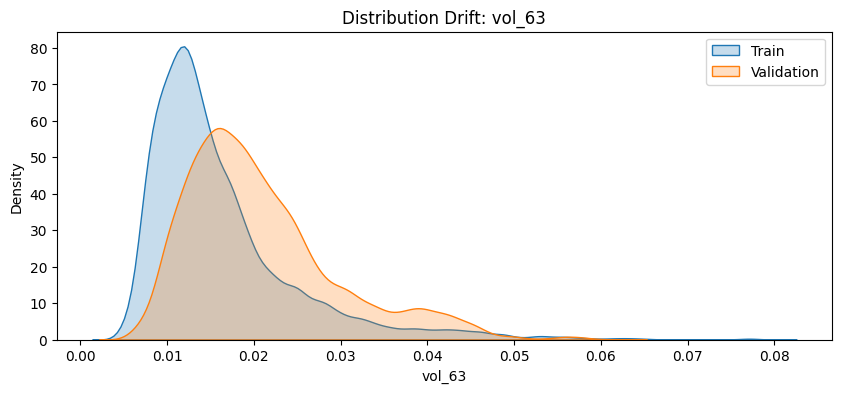

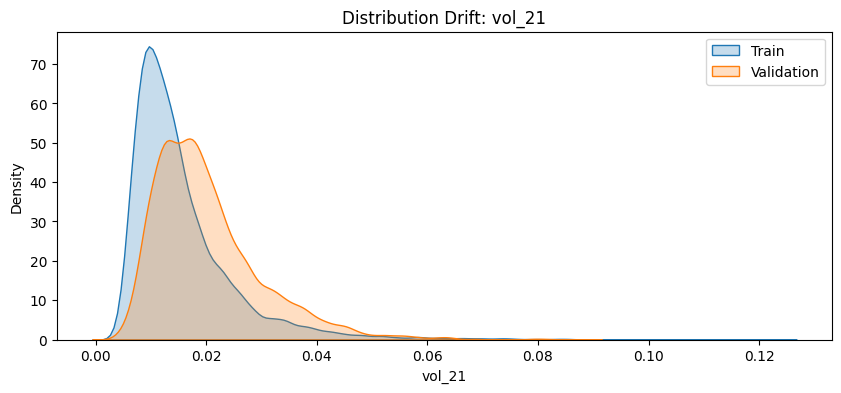

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

top_drift_feats = drift_df.head(5)["feature"]

for feat in top_drift_feats:
    plt.figure(figsize=(10,4))
    sns.kdeplot(train_df[feat], label="Train", fill=True)
    sns.kdeplot(val_df[feat], label="Validation", fill=True)
    plt.title(f"Distribution Drift: {feat}")
    plt.legend()
    plt.show()

--------

IC Drift

In [37]:
train_df

,date,ticker,fwd_return_5d,dollar_volume,price_ma_ratio_5,price_ma_ratio_10,price_ma_ratio_21,price_ma_ratio_63,price_ma_ratio_252,pos_days_21,...,downside_vol_1d,downside_vol_5d,vol_avg_5,vol_avg_21,vol_avg_63,dollar_vol_log,volume_trend,mom_x_vol_5,mom_x_vol_21,mom_x_vol_63
0,2011-01-03,AAPL,0.039081,4.399815e+09,0.013095,0.015186,0.022646,0.053737,0.266111,0.571429,...,0.002118,0.001247,227040800.0,3.092279e+08,4.488507e+08,22.204828,-8.312502e+06,3.419588e+06,1.109984e+07,8.204138e+07
1,2011-01-04,AAPL,0.031242,3.070944e+09,0.014752,0.017638,0.025883,0.056965,0.270454,0.619048,...,0.002138,0.001247,253672160.0,3.076559e+08,4.457890e+08,21.845251,-7.844913e+06,4.536055e+06,1.342301e+07,6.533927e+07
2,2011-01-05,AAPL,0.031198,2.559542e+09,0.017622,0.022883,0.032167,0.063198,0.278453,0.619048,...,0.002138,0.001247,272148240.0,2.984672e+08,4.391961e+08,21.663094,-6.510211e+06,7.287014e+06,1.291194e+07,6.805336e+07
3,2011-01-06,AAPL,0.035807,3.006965e+09,0.010599,0.019381,0.028983,0.059955,0.275035,0.619048,...,0.001858,0.001247,300735120.0,2.941327e+08,4.374823e+08,21.824197,-5.156353e+06,9.356793e+06,1.434567e+07,6.732704e+07
4,2011-01-07,AAPL,0.036773,3.144450e+09,0.009545,0.022770,0.034058,0.065287,0.281753,0.619048,...,0.001858,0.001247,324419760.0,2.936563e+08,4.319828e+08,21.868905,-4.528018e+06,1.363817e+07,1.382247e+07,6.177061e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109279,2021-12-27,XOM,0.026660,6.762030e+08,0.019403,0.015589,0.010677,-0.002264,0.102931,0.571429,...,0.010966,0.017684,16362700.0,2.192815e+07,2.103481e+07,20.332004,-4.292123e+05,5.069886e+05,-5.492418e+05,1.213762e+06
109280,2021-12-28,XOM,0.068731,6.840421e+08,0.007710,0.012208,0.007066,-0.006141,0.097630,0.571429,...,0.008782,0.017253,14555040.0,2.134727e+07,2.064055e+07,20.343530,-5.044144e+05,6.224543e+05,1.533547e+05,8.952968e+05
109281,2021-12-29,XOM,0.091578,6.755398e+08,-0.003227,0.003990,-0.001407,-0.015360,0.086314,0.523810,...,0.008745,0.017253,13141980.0,2.105142e+07,2.047088e+07,20.331023,-6.505783e+05,1.411958e+05,-1.503915e+05,7.151160e+05
109282,2021-12-30,XOM,0.123869,6.297245e+08,-0.008449,-0.001134,-0.008019,-0.021845,0.078277,0.523810,...,0.006973,0.017101,12718380.0,1.995430e+07,2.016375e+07,20.260793,-5.699277e+05,-4.170689e+04,3.167861e+05,9.553846e+05


In [38]:
def compute_ic(df, feature, target="fwd_return_5d"):
    return df.groupby("date").apply(
        lambda x: x[feature].corr(x[target], method="spearman")
    )

In [39]:
ic_drift = []

for feat in feature_cols:
    ic_train = compute_ic(train_df, feat)
    ic_val   = compute_ic(val_df, feat)

    ic_drift.append({
        "feature": feat,
        "ic_train": ic_train.mean(),
        "ic_val": ic_val.mean(),
        "ic_drop": ic_val.mean() - ic_train.mean()
    })

ic_drift_df = pd.DataFrame(ic_drift).sort_values("ic_drop")
ic_drift_df.head(10)

/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_28121/2480218738.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date").apply(
/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_28121/2480218738.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date").apply(
/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_28121/2480218738.py:2: Deprec

,feature,ic_train,ic_val,ic_drop
17,vol_5,0.024596,-0.022595,-0.047191
18,vol_10,0.027638,-0.018060,-0.045698
19,vol_21,0.026445,-0.009369,-0.035815
20,vol_63,0.027087,-0.006909,-0.033996
23,hl_range,0.020819,-0.011889,-0.032708
16,rev_5d,0.016885,-0.010536,-0.027421
24,downside_vol_1d,0.017557,-0.008713,-0.026270
15,rev_1d,0.015826,-0.006964,-0.022790
21,vol_ratio_21_63,0.000151,-0.019157,-0.019308
22,vol_ratio_5_21,0.005321,-0.009640,-0.014961


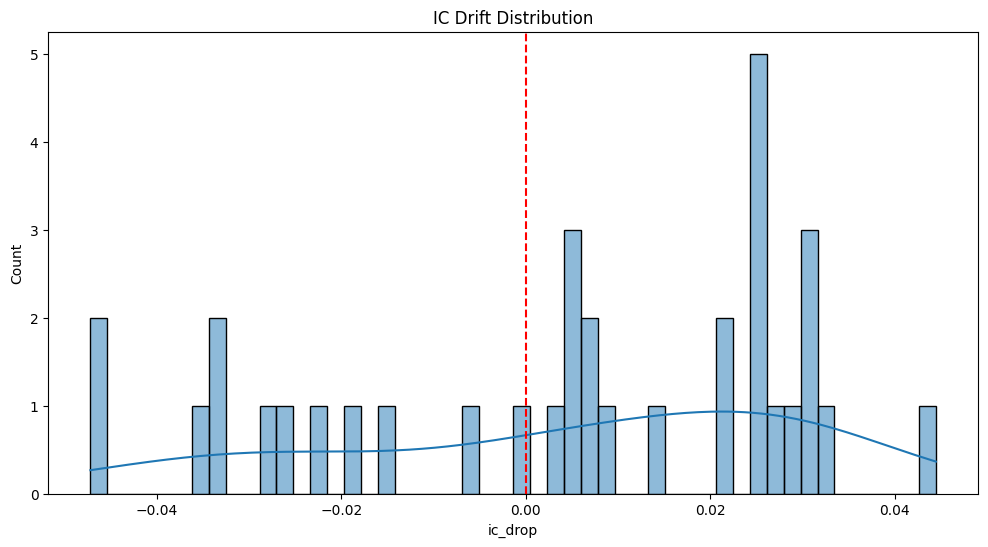

In [40]:
plt.figure(figsize=(12,6))
sns.histplot(ic_drift_df["ic_drop"], bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("IC Drift Distribution")
plt.show()

Statistical Drift Tests (Train vs Val)

In [ ]:
def newey_west_tstat(diff_series, lags=5):
    X = np.ones(len(diff_series))
    model = sm.OLS(diff_series, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': lags}
    )
    return model.tvalues[0]

In [49]:
ic_drift_stats = []

for feat in feature_cols:
    ic_train = compute_ic(train_df, feat).dropna()
    ic_val   = compute_ic(val_df, feat).dropna()

    if len(ic_train) < 30 or len(ic_val) < 30:
        continue

    diff = ic_val - ic_train.mean()

    if len(diff) < 30:
        continue

    t_stat = newey_west_tstat(diff)

    ic_drift_stats.append({
        "feature": feat,
        "nw_tstat": t_stat
    })

ic_drift_test_df = pd.DataFrame(ic_drift_stats)

/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_28121/2480218738.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date").apply(
/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_28121/2480218738.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date").apply(
/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_28121/147658953.py:10: Future

In [50]:
ic_drift_test_df

,feature,nw_tstat
0,dollar_volume,0.258845
1,price_ma_ratio_5,1.120765
2,price_ma_ratio_10,1.276137
3,price_ma_ratio_21,1.089919
4,price_ma_ratio_63,0.920690
5,price_ma_ratio_252,0.677986
6,pos_days_21,1.280446
7,z_price_21,1.797182
8,z_price_63,0.905057
9,z_return_1d_5,1.393455


In [44]:
drift_df

,feature,ks_stat,ks_pvalue,wasserstein
0,dollar_volume,0.396801,0.000000e+00,1.746549e+09
29,dollar_vol_log,0.396801,0.000000e+00,8.661470e-01
5,price_ma_ratio_252,0.310831,0.000000e+00,1.150406e-01
20,vol_63,0.305965,0.000000e+00,4.747506e-03
19,vol_21,0.277739,0.000000e+00,4.739859e-03
24,downside_vol_1d,0.254745,0.000000e+00,2.851977e-03
18,vol_10,0.250266,0.000000e+00,4.621770e-03
25,downside_vol_5d,0.246709,0.000000e+00,6.636532e-03
23,hl_range,0.246444,0.000000e+00,6.063795e-03
17,vol_5,0.220265,0.000000e+00,4.467616e-03


In [45]:
ic_drift_df

,feature,ic_train,ic_val,ic_drop
17,vol_5,0.024596,-0.022595,-0.047191
18,vol_10,0.027638,-0.018060,-0.045698
19,vol_21,0.026445,-0.009369,-0.035815
20,vol_63,0.027087,-0.006909,-0.033996
23,hl_range,0.020819,-0.011889,-0.032708
16,rev_5d,0.016885,-0.010536,-0.027421
24,downside_vol_1d,0.017557,-0.008713,-0.026270
15,rev_1d,0.015826,-0.006964,-0.022790
21,vol_ratio_21_63,0.000151,-0.019157,-0.019308
22,vol_ratio_5_21,0.005321,-0.009640,-0.014961


In [51]:
final_drift = drift_df.merge(ic_drift_df, on="feature") \
                       .merge(ic_drift_test_df, on="feature", how="left")

final_drift.sort_values(["ks_stat","ic_drop"], ascending=False).head(15)

,feature,ks_stat,ks_pvalue,wasserstein,ic_train,ic_val,ic_drop,nw_tstat
0,dollar_volume,0.396801,0.000000e+00,1.746549e+09,-0.003609,0.003712,0.007321,0.258845
1,dollar_vol_log,0.396801,0.000000e+00,8.661470e-01,-0.003609,0.003712,0.007321,0.258845
2,price_ma_ratio_252,0.310831,0.000000e+00,1.150406e-01,0.012311,0.033332,0.021021,0.677986
3,vol_63,0.305965,0.000000e+00,4.747506e-03,0.027087,-0.006909,-0.033996,-0.821900
4,vol_21,0.277739,0.000000e+00,4.739859e-03,0.026445,-0.009369,-0.035815,-0.928794
5,downside_vol_1d,0.254745,0.000000e+00,2.851977e-03,0.017557,-0.008713,-0.026270,-0.807994
6,vol_10,0.250266,0.000000e+00,4.621770e-03,0.027638,-0.018060,-0.045698,-1.265216
7,downside_vol_5d,0.246709,0.000000e+00,6.636532e-03,0.015319,0.009727,-0.005592,-0.186896
8,hl_range,0.246444,0.000000e+00,6.063795e-03,0.020819,-0.011889,-0.032708,-1.100763
9,vol_5,0.220265,0.000000e+00,4.467616e-03,0.024596,-0.022595,-0.047191,-1.454431


In [52]:
ic_drift_test_df

,feature,nw_tstat
0,dollar_volume,0.258845
1,price_ma_ratio_5,1.120765
2,price_ma_ratio_10,1.276137
3,price_ma_ratio_21,1.089919
4,price_ma_ratio_63,0.920690
5,price_ma_ratio_252,0.677986
6,pos_days_21,1.280446
7,z_price_21,1.797182
8,z_price_63,0.905057
9,z_return_1d_5,1.393455


------